# Strong-constraint 4D-Var on a 1-D advection–diffusion model

A runnable **twin experiment** for four-dimensional variational data assimilation
(4D-Var; Le Dimet & Talagrand 1986, Talagrand & Courtier 1987), built up step by step:
a hand-written **adjoint model** provides the gradient, verified against finite
differences, and L-BFGS recovers both the **initial condition** and (as a bonus) a
**model parameter** — the diffusivity $\kappa$ — from sparse, noisy observations.
This forward–adjoint–optimize loop is the same machinery behind operational weather
analysis (ECMWF's IFS) and ocean state estimation (ECCO, SOSE).

> Strictly this toy has **one space dimension + time**, so it is really a baby
> "2D-Var" 😄 — but the essential 4D-Var idea is exactly here: fit a **model
> trajectory** to observations spread over a **time window**.

See `docs/fourdvar_notes.md` for the full derivation of every step.

**Requirements:** `numpy`, `scipy`, `matplotlib` — see `requirements.txt`.


In [1]:
# If a package is missing:  pip install -r ../requirements.txt
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
rng = np.random.default_rng(0)
print("imports OK — numpy", np.__version__)


imports OK — numpy 1.26.4


## 1. The forward model:  x_{n+1} = A x_n

We discretise the tracer equation   ∂T/∂t + u ∂T/∂x = κ ∂²T/∂x²   on a periodic
ring of N points. With grid spacing dx and time step dt, **one step** is:

```
T_i^{n+1} = T_i^n
            - (u·dt/dx)·(T_i^n - T_{i-1}^n)                  # advection (upwind, u>0)
            + (κ·dt/dx²)·(T_{i+1}^n - 2·T_i^n + T_{i-1}^n)   # diffusion (centered)
```

Every term is **linear** in T, so the whole step is a **matrix multiply**
`x_{n+1} = A @ x_n`, where A is built once from the two stencils.
Applying it repeatedly gives the trajectory

```
x_n = A^n x_0        (n = 0, 1, ..., M)
```

so the **entire trajectory is determined by the initial state x_0** — the fact
4D-Var rests on. (Bonus: because A is an explicit matrix, the adjoint we need
later is simply its transpose `A.T`.)


In [2]:
N   = 100            # grid points
L   = 1.0            # domain length
dx  = L / N
u   = 1.0            # advection speed
kap = 2e-3           # diffusivity kappa
dt  = 0.4 * dx / u   # time step (CFL-safe)
M   = 120            # number of time steps in the assimilation window

ca = u * dt / dx          # advection Courant number  (u·dt/dx)
cd = kap * dt / dx**2     # diffusion number          (κ·dt/dx²)

# build the one-step propagator A once:  x_{n+1} = A @ x_n
A = np.zeros((N, N))
for i in range(N):
    A[i, i]           += 1 - ca - 2 * cd
    A[i, (i - 1) % N] += ca + cd          # upwind advection (from the left) + diffusion
    A[i, (i + 1) % N] += cd               # diffusion (from the right)

def forward_model(x0):
    """Given the initial condition x0, return the WHOLE trajectory.

    traj[n] is the state at time step n (n = 0..M). It is built by repeatedly
    applying the one-step propagator A:

        traj[0]   = x0
        traj[n+1] = A @ traj[n]      <=>      traj[n] = A^n @ x0

    So the trajectory is *completely determined* by the initial state x0.
    """
    traj = np.empty((M + 1, N))
    traj[0] = x0
    for n in range(M):
        traj[n + 1] = A @ traj[n]
    return traj

print("A shape:", A.shape, "| one step is  x_{n+1} = A @ x_n")
print(f"Courant ca = {ca:.3f} (<1 ok),  diffusion cd = {cd:.3f} (<0.5 ok)  -> stable")


A shape: (100, 100) | one step is  x_{n+1} = A @ x_n
Courant ca = 0.400 (<1 ok),  diffusion cd = 0.080 (<0.5 ok)  -> stable


### Quick demo: a bump is carried along and smoothed
Let's *see* `forward_model` in action — start from a single bump and look at a
few snapshots, then the whole space–time picture (a Hovmöller diagram).


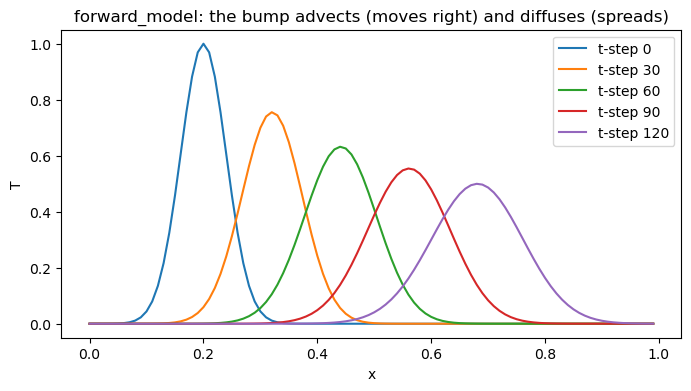

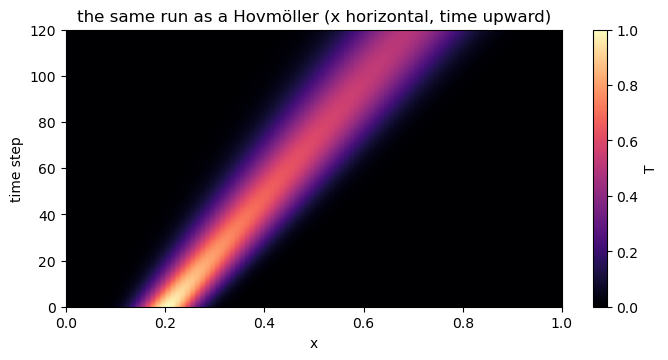

In [3]:
xgrid = np.linspace(0, L, N, endpoint=False)
demo0 = np.exp(-0.5 * ((xgrid - 0.20) / 0.04) ** 2)   # a demo bump at x = 0.2
demo  = forward_model(demo0)

fig, ax = plt.subplots(figsize=(8, 4))
for n in [0, 30, 60, 90, 120]:
    ax.plot(xgrid, demo[n], label=f"t-step {n}")
ax.set_title("forward_model: the bump advects (moves right) and diffuses (spreads)")
ax.set_xlabel("x"); ax.set_ylabel("T"); ax.legend(); plt.show()

fig, ax = plt.subplots(figsize=(8, 3.6))
im = ax.imshow(demo, aspect="auto", origin="lower", extent=[0, L, 0, M], cmap="magma")
ax.set_title("the same run as a Hovm\u00f6ller (x horizontal, time upward)")
ax.set_xlabel("x"); ax.set_ylabel("time step"); fig.colorbar(im, label="T"); plt.show()


## 2. Twin experiment — make a "ground truth"
A twin experiment is the standard way to test data assimilation: we **invent a
truth**, generate fake observations from it, then check whether the method can
recover the truth (so we always know the right answer).

`x0_true` is the **true initial condition** (a Gaussian bump at x = 0.3);
`traj_true` is the **true trajectory** — together, the **ground truth** that we
will pretend not to know.


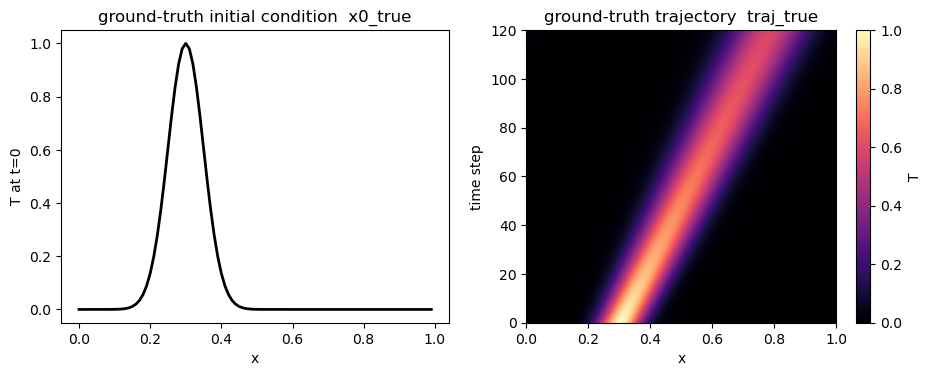

In [4]:
x0_true   = np.exp(-0.5 * ((xgrid - 0.30) / 0.05) ** 2)   # TRUE initial condition
traj_true = forward_model(x0_true)                        # TRUE trajectory (the ground truth)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(xgrid, x0_true, 'k-', lw=2)
axes[0].set_title("ground-truth initial condition  x0_true")
axes[0].set_xlabel("x"); axes[0].set_ylabel("T at t=0")
im = axes[1].imshow(traj_true, aspect="auto", origin="lower", extent=[0, L, 0, M], cmap="magma")
axes[1].set_title("ground-truth trajectory  traj_true")
axes[1].set_xlabel("x"); axes[1].set_ylabel("time step")
fig.colorbar(im, ax=axes[1], label="T"); plt.show()


## 3. Observations — sparse and noisy
We pretend we can only measure T at a few grid points, at a few times, with noise.


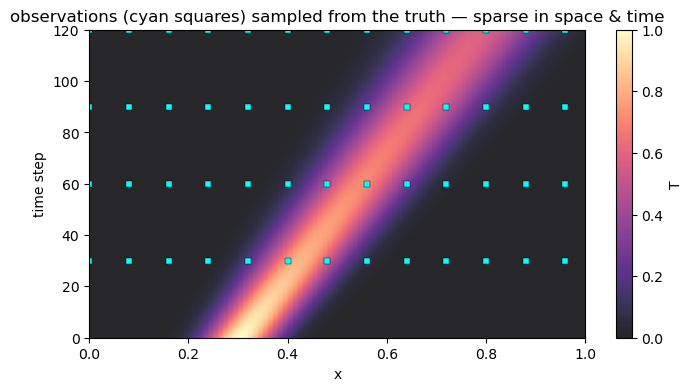

In [5]:
obs_times = [30, 60, 90, 120]      # time steps where we have observations
obs_idx   = np.arange(0, N, 8)     # observed grid points (every 8th)

def H(state):
    """observation operator: pick out the observed grid points."""
    return state[obs_idx]

sigma_o = 0.02    # observation error std  (R = sigma_o^2 I)
sigma_b = 0.5     # background error std   (B = sigma_b^2 I) — a weak prior

obs = {n: H(traj_true[n]) + sigma_o * rng.standard_normal(obs_idx.size) for n in obs_times}

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(traj_true, aspect="auto", origin="lower", extent=[0, L, 0, M], cmap="magma", alpha=0.85)
for n in obs_times:
    ax.scatter(obs_idx * dx, np.full(obs_idx.size, n), s=16, c="cyan", marker="s", edgecolors="k", linewidths=0.3)
ax.set_title("observations (cyan squares) sampled from the truth — sparse in space & time")
ax.set_xlabel("x"); ax.set_ylabel("time step"); fig.colorbar(im, label="T"); plt.show()


## 4. A wrong first guess (the background x_b)
4D-Var has to start somewhere; we give it a deliberately wrong guess — a bump
in the wrong place. Its trajectory will not match the observations, and that
mismatch is exactly what we will minimise.


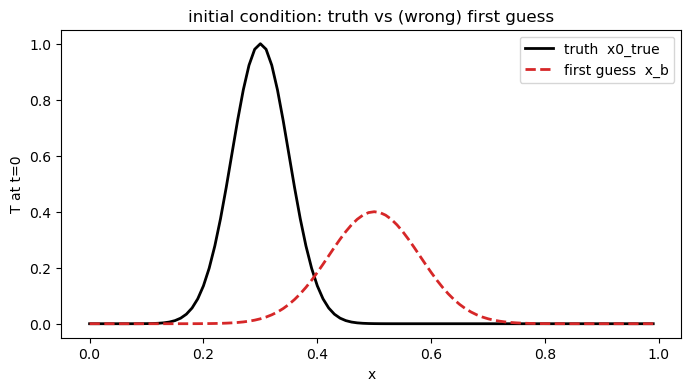

In [6]:
x_b = 0.4 * np.exp(-0.5 * ((xgrid - 0.50) / 0.08) ** 2)   # WRONG first guess

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(xgrid, x0_true, 'k-',  lw=2,  label="truth  x0_true")
ax.plot(xgrid, x_b,     'C3--', lw=2, label="first guess  x_b")
ax.set_title("initial condition: truth vs (wrong) first guess")
ax.set_xlabel("x"); ax.set_ylabel("T at t=0"); ax.legend(); plt.show()


## 5. Cost J(x0) and its gradient via the ADJOINT
- `cost(x0)`: run the model forward, add up how far the trajectory is from the
  observations (plus how far x0 is from the prior x_b). This is the **forward** sweep.
- `grad(x0)`: the **backward (adjoint)** sweep — propagate the misfits backward
  with `A.T` and inject the observation residuals. This is exactly
  **backpropagation**, through the model's time steps.


In [7]:
def cost(x0):
    traj = forward_model(x0)
    J = 0.5 * np.sum((x0 - x_b) ** 2) / sigma_b**2          # background term
    for n in obs_times:
        d = H(traj[n]) - obs[n]
        J += 0.5 * np.sum(d ** 2) / sigma_o**2               # observation term
    return J

def grad(x0):
    """dJ/dx0 by the adjoint (one backward sweep)."""
    traj = forward_model(x0)
    lam  = np.zeros(N)
    for n in range(M, -1, -1):
        if n in obs:                          # inject the observation residual
            d = H(traj[n]) - obs[n]
            adj = np.zeros(N); adj[obs_idx] = d / sigma_o**2
            lam = lam + adj
        if n > 0:
            lam = A.T @ lam                   # propagate the adjoint back one step
    return (x0 - x_b) / sigma_b**2 + lam

print(f"cost at the first guess x_b : J = {cost(x_b):8.1f}   (large = far from the observations)")
print(f"cost at the truth x0_true   : J = {cost(x0_true):8.1f}   (small = only the obs noise is left)")


cost at the first guess x_b : J =   4230.0   (large = far from the observations)
cost at the truth x0_true   : J =     42.4   (small = only the obs noise is left)


### Gradient check
Always verify a hand-written adjoint against finite differences (this is how
adjoints are debugged in MITgcm / ECCO too). Should match to ~1e-8 or better.


In [8]:
x_test = x_b + 0.1 * rng.standard_normal(N)
g_adj  = grad(x_test)
eps    = 1e-6
g_fd   = np.zeros(N)
for i in range(N):
    e = np.zeros(N); e[i] = eps
    g_fd[i] = (cost(x_test + e) - cost(x_test - e)) / (2 * eps)
print(f"adjoint-vs-finite-difference relative error = "
      f"{np.linalg.norm(g_adj - g_fd) / np.linalg.norm(g_fd):.2e}   (tiny = adjoint is correct)")


adjoint-vs-finite-difference relative error = 8.36e-10   (tiny = adjoint is correct)


## 6. Minimise (the 4D-Var solve)
L-BFGS uses our adjoint gradient. Because the model is linear and the cost
quadratic, J is convex → a unique minimum. We print J at every iteration so you
can watch it fall.


In [9]:
history = [cost(x_b)]
def cb(xk):
    history.append(cost(xk))
    print(f"  iter {len(history)-1:2d}:  J = {history[-1]:.3f}")

print(f"start:  J = {history[0]:.3f}")
res = minimize(cost, x_b.copy(), jac=grad, method="L-BFGS-B",
               callback=cb, options={"maxiter": 200, "gtol": 1e-10})
x0_analysis = res.x
print(f"\nconverged in {res.nit} iterations,  final J = {res.fun:.3f}")
print(f"|| analysis    - truth || = {np.linalg.norm(x0_analysis - x0_true):.3f}")
print(f"|| first guess - truth || = {np.linalg.norm(x_b - x0_true):.3f}   (4D-Var made it much smaller)")


start:  J = 4229.975
  iter  1:  J = 1958.701
  iter  2:  J = 93.912
  iter  3:  J = 56.914
  iter  4:  J = 39.296
  iter  5:  J = 37.657
  iter  6:  J = 36.721
  iter  7:  J = 36.387
  iter  8:  J = 36.204
  iter  9:  J = 36.115
  iter 10:  J = 35.983
  iter 11:  J = 35.949
  iter 12:  J = 35.840
  iter 13:  J = 35.707
  iter 14:  J = 35.663
  iter 15:  J = 35.457
  iter 16:  J = 35.386
  iter 17:  J = 35.316
  iter 18:  J = 35.258
  iter 19:  J = 35.241
  iter 20:  J = 35.220
  iter 21:  J = 35.213
  iter 22:  J = 35.205
  iter 23:  J = 35.198
  iter 24:  J = 35.188
  iter 25:  J = 35.168
  iter 26:  J = 35.166
  iter 27:  J = 35.155
  iter 28:  J = 35.153
  iter 29:  J = 35.151
  iter 30:  J = 35.150
  iter 31:  J = 35.149
  iter 32:  J = 35.149
  iter 33:  J = 35.148
  iter 34:  J = 35.148
  iter 35:  J = 35.147
  iter 36:  J = 35.147
  iter 37:  J = 35.147
  iter 38:  J = 35.147
  iter 39:  J = 35.147
  iter 40:  J = 35.147
  iter 41:  J = 35.147
  iter 42:  J = 35.147
  iter 43: 

## 7. Result
The recovered initial condition vs the truth and the first guess, and the cost curve.


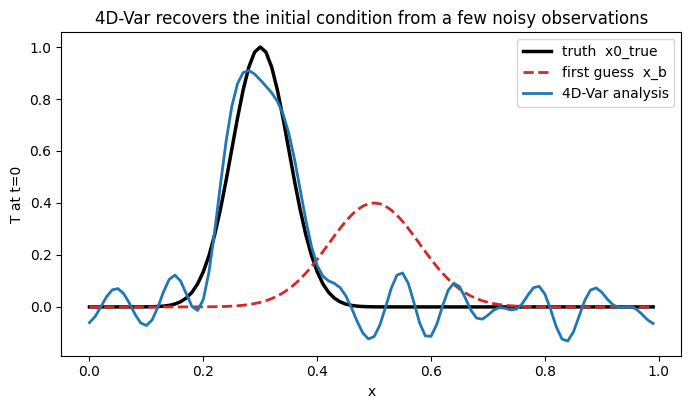

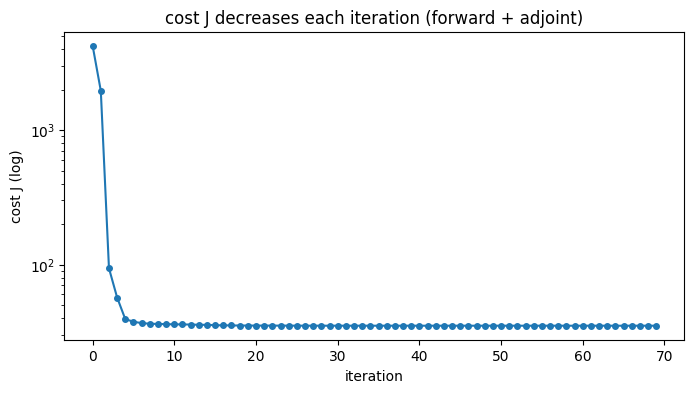

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(xgrid, x0_true,     'k-',   lw=2.5, label="truth  x0_true")
ax.plot(xgrid, x_b,         'C3--', lw=2,   label="first guess  x_b")
ax.plot(xgrid, x0_analysis, 'C0-',  lw=2,   label="4D-Var analysis")
ax.set_title("4D-Var recovers the initial condition from a few noisy observations")
ax.set_xlabel("x"); ax.set_ylabel("T at t=0"); ax.legend(); plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(range(len(history)), history, 'o-', ms=4)
ax.set_title("cost J decreases each iteration (forward + adjoint)")
ax.set_xlabel("iteration"); ax.set_ylabel("cost J (log)"); plt.show()


## 8. Bonus — estimating the parameter κ (parameter estimation)
So far κ was fixed and we solved for x₀. Here we do the opposite — a
**parameter-estimation twin experiment**: assume the initial state is known and
ask whether the observations can recover the **diffusivity κ** itself.
In ECCO/SOSE the mixing coefficients (κ_v, Redi, GM) are exactly this kind of
control variable.

Now the model depends on κ through A(κ) = A_adv + κ·(dt/dx²)·L, so the **same
adjoint also gives the parameter gradient** dJ/dκ = Σ_n a_{n+1}ᵀ (dA/dκ) x_n.


kappa grad-check: adjoint=2.9685e+04  finite-diff=2.9685e+04
recovered kappa = 1.8581e-03   (true 2.0e-03, first guess 8e-3)


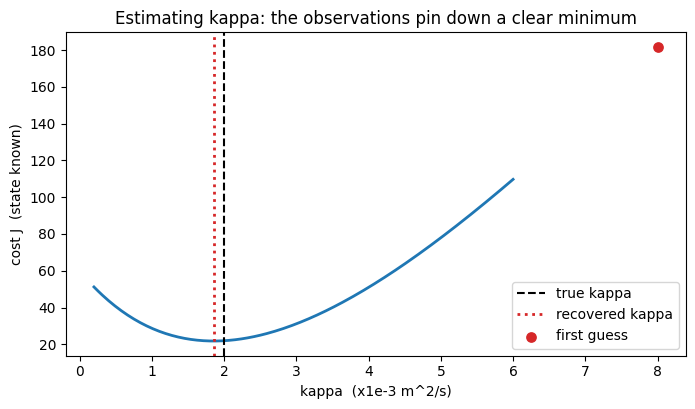

In [11]:
# build A as an explicit function of kappa:  A(kappa) = A_adv + kappa*(dt/dx^2)*Lap
Lap = np.zeros((N, N))
for i in range(N):
    Lap[i, i]           += -2
    Lap[i, (i - 1) % N] += 1
    Lap[i, (i + 1) % N] += 1
cdiff = dt / dx**2                    # hence dA/dkappa = cdiff * Lap
A_adv = np.zeros((N, N))              # the kappa-independent part (identity + advection)
for i in range(N):
    A_adv[i, i]           += 1 - ca
    A_adv[i, (i - 1) % N] += ca

def forward_kappa(x0, kappa):
    A = A_adv + kappa * cdiff * Lap
    traj = np.empty((M + 1, N)); traj[0] = x0
    for n in range(M):
        traj[n + 1] = A @ traj[n]
    return traj, A

def cost_kappa(kappa):
    traj, _ = forward_kappa(x0_true, kappa)             # state known (x0 = x0_true)
    return sum(0.5 * np.sum((H(traj[n]) - obs[n])**2) / sigma_o**2 for n in obs_times)

def grad_kappa(kappa):
    """dJ/dkappa by the adjoint: the same backward sweep, but also accumulate
    dJ/dkappa += a_n^T (dA/dkappa) x_{n-1} as the adjoint propagates back."""
    traj, A = forward_kappa(x0_true, kappa)
    dAdk = cdiff * Lap
    a = np.zeros(N); dJdk = 0.0
    for n in range(M, -1, -1):
        if n in obs:
            d = H(traj[n]) - obs[n]
            f = np.zeros(N); f[obs_idx] = d / sigma_o**2
            a = a + f
        if n >= 1:
            dJdk += a @ (dAdk @ traj[n - 1])
            a = A.T @ a
    return dJdk

# gradient check for the parameter gradient
k0 = 5e-3; epsk = 1e-7
print(f"kappa grad-check: adjoint={grad_kappa(k0):.4e}  "
      f"finite-diff={(cost_kappa(k0+epsk)-cost_kappa(k0-epsk))/(2*epsk):.4e}")

# recover kappa from a wrong first guess (8e-3); the true value is kap = 2e-3
resk = minimize(lambda z: cost_kappa(z[0]), [8e-3], jac=lambda z: [grad_kappa(z[0])],
                method="L-BFGS-B", bounds=[(1e-5, 1e-1)], options={"gtol": 1e-12})
print(f"recovered kappa = {resk.x[0]:.4e}   (true {kap:.1e}, first guess 8e-3)")

# the cost as a function of kappa: a clear bowl with its minimum near the truth
ks = np.linspace(0.2e-3, 6e-3, 200)
Jk = np.array([cost_kappa(k) for k in ks])
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(ks*1e3, Jk, 'C0-', lw=2)
ax.axvline(kap*1e3,       color='k',  ls='--', label='true kappa')
ax.axvline(resk.x[0]*1e3, color='C3', ls=':', lw=2, label='recovered kappa')
ax.scatter([8.0], [cost_kappa(8e-3)], c='C3', s=45, zorder=5, label='first guess')
ax.set_xlabel("kappa  (x1e-3 m^2/s)"); ax.set_ylabel("cost J  (state known)")
ax.set_title("Estimating kappa: the observations pin down a clear minimum")
ax.legend(); plt.show()


## References

- Le Dimet, F.-X., & Talagrand, O. (1986). Variational algorithms for analysis and
  assimilation of meteorological observations: theoretical aspects. *Tellus A*, 38(2), 97–110.
- Talagrand, O., & Courtier, P. (1987). Variational assimilation of meteorological
  observations with the adjoint vorticity equation. I: Theory. *QJRMS*, 113(478), 1311–1328.
- Courtier, P., Thépaut, J.-N., & Hollingsworth, A. (1994). A strategy for operational
  implementation of 4D-Var, using an incremental approach. *QJRMS*, 120(519), 1367–1387.
- Wunsch, C., & Heimbach, P. (2007). Practical global oceanic state estimation.
  *Physica D*, 230(1–2), 197–208. (ECCO)
- Mazloff, M. R., Heimbach, P., & Wunsch, C. (2010). An eddy-permitting Southern Ocean
  state estimate. *Journal of Physical Oceanography*, 40(5), 880–899. (SOSE)
